## Miguel Angel Alvarez Guzman
### CC 1000871173

In [71]:
! pip install OpenCV-Python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\migue\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### **Carga y Normalizacion**

--- Antes de la Normalización ---
Dimensiones de la imagen: (150, 150, 3)
Tipo de dato: uint8
Valor mínimo del píxel: 0
Valor máximo del píxel: 255

--- Después de la Normalización ---
Dimensiones de la imagen: (150, 150, 3)
Tipo de dato: float32
Valor mínimo del píxel: 0.0
Valor máximo del píxel: 1.0


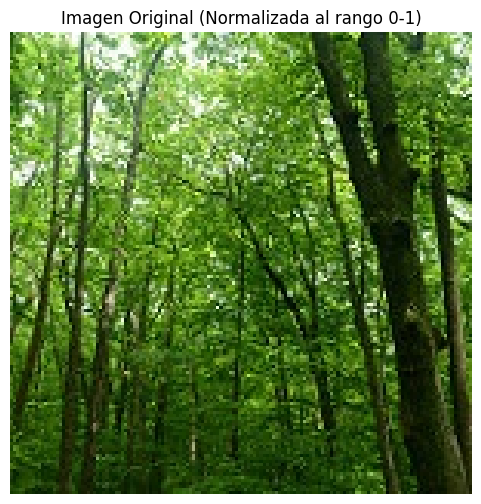

In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar la imagen
ruta_imagen = 'seg_train\\seg_train\\forest\\8.jpg' 

imagen_bgr = cv2.imread(ruta_imagen)
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

print("--- Antes de la Normalización ---")
print(f"Dimensiones de la imagen: {imagen_rgb.shape}") 
print(f"Tipo de dato: {imagen_rgb.dtype}") 
print(f"Valor mínimo del píxel: {np.min(imagen_rgb)}")   
print(f"Valor máximo del píxel: {np.max(imagen_rgb)}")   

# 2. Normalizar la imagen
imagen_normalizada = imagen_rgb.astype('float32') / 255.0

print("\n--- Después de la Normalización ---")
print(f"Dimensiones de la imagen: {imagen_normalizada.shape}")
print(f"Tipo de dato: {imagen_normalizada.dtype}") 
print(f"Valor mínimo del píxel: {np.min(imagen_normalizada)}") 
print(f"Valor máximo del píxel: {np.max(imagen_normalizada)}") 

# 3. Visualización
plt.figure(figsize=(6, 6))
plt.imshow(imagen_normalizada)
plt.title("Imagen Original (Normalizada al rango 0-1)")
plt.axis('off') # Ocultamos los ejes con números para que se vea más limpio
plt.show()

### **Contaminacion con ruido**

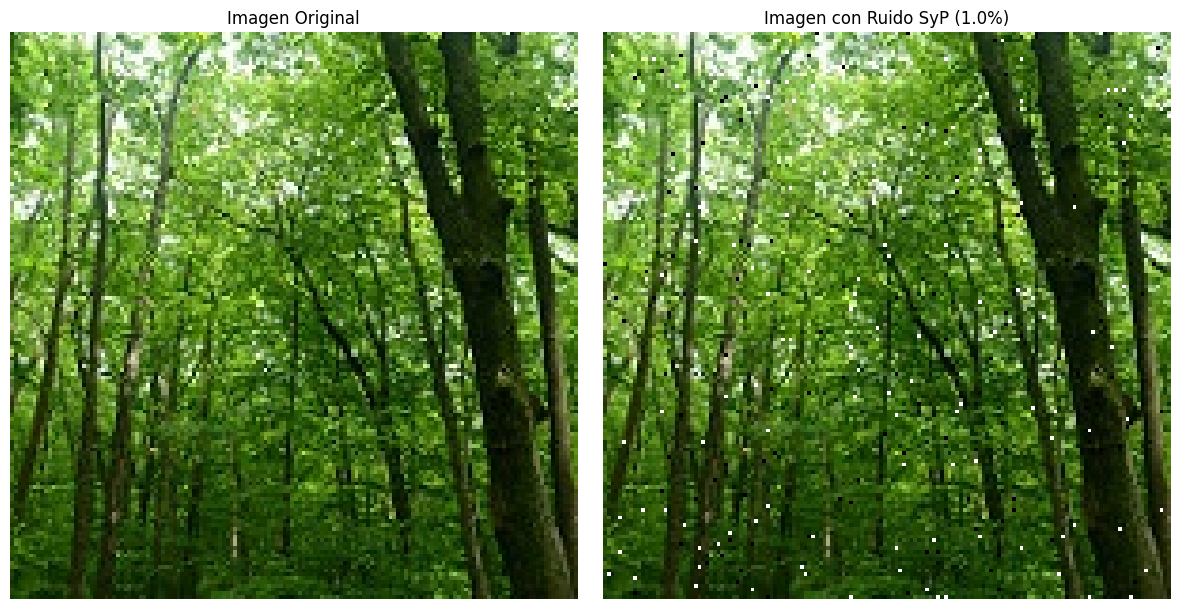

In [73]:
# 1. Definir la cantidad de ruido
probabilidad_ruido = 0.01 
imagen_ruidosa = np.copy(imagen_normalizada)
filas, columnas, canales = imagen_ruidosa.shape

# 2. Generar una matriz aleatoria
matriz_aleatoria = np.random.rand(filas, columnas)

# 3. Crear las máscaras lógicas para la sal y la pimienta
mascara_sal = matriz_aleatoria < (probabilidad_ruido / 2)
mascara_pimienta = (matriz_aleatoria >= (probabilidad_ruido / 2)) & (matriz_aleatoria < probabilidad_ruido)

# 4. Aplicar el ruido
imagen_ruidosa[mascara_sal] = [1.0, 1.0, 1.0] 
imagen_ruidosa[mascara_pimienta] = [0.0, 0.0, 0.0]

# 5. Visualización comparativa
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(imagen_normalizada)
ax[0].set_title("Imagen Original")
ax[0].axis('off')

ax[1].imshow(imagen_ruidosa)
ax[1].set_title(f"Imagen con Ruido SyP ({probabilidad_ruido*100}%)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

### **Filtrado**

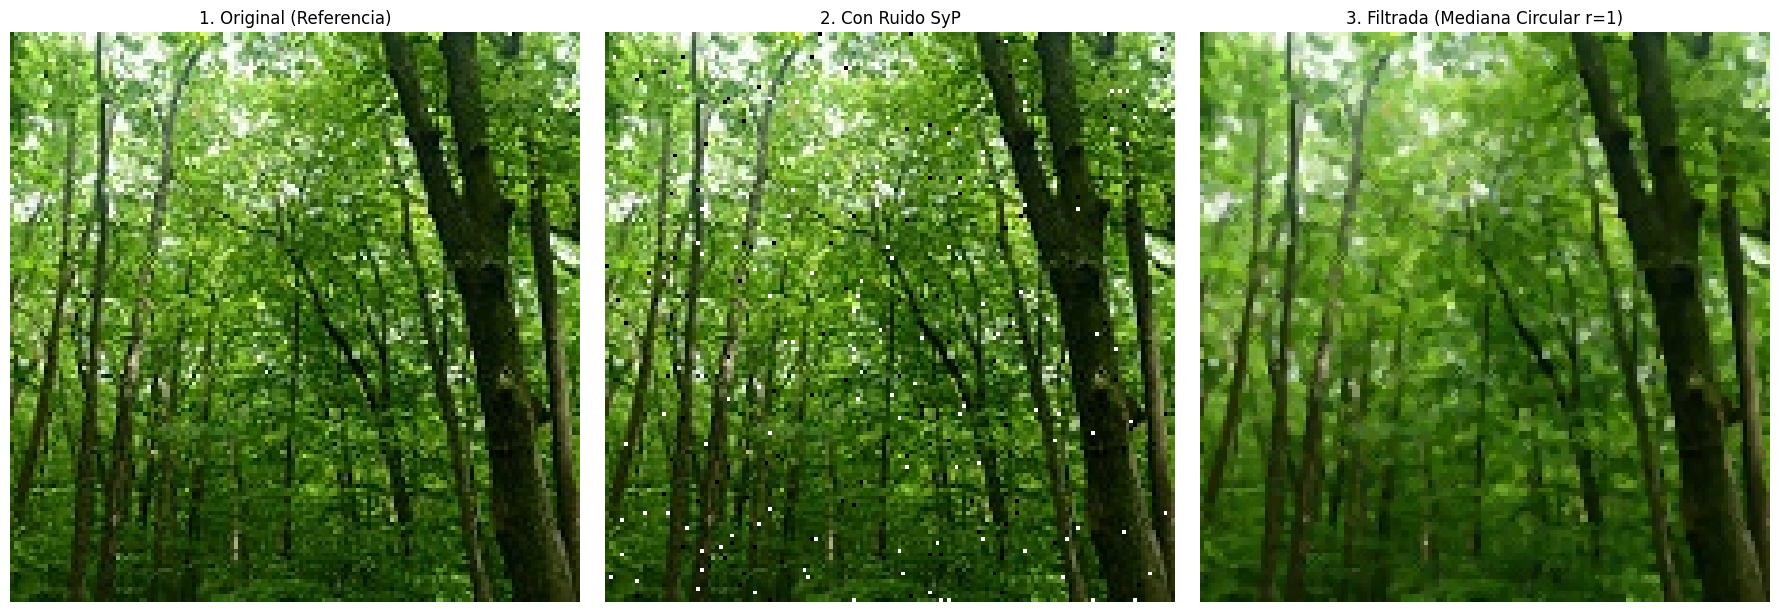

Forma de la vecindad circular (máscara):
[[0 1 0]
 [1 1 1]
 [0 1 0]]


In [74]:
from scipy.ndimage import median_filter
from skimage.morphology import disk

# 1. Definir el radio de la vecindad circular
radio = 1
mascara_circular = disk(radio)

# 2. Aplicar el filtro de mediana
imagen_filtrada = np.zeros_like(imagen_ruidosa)

for i in range(3): # Iteramos sobre los canales R, G y B
    imagen_filtrada[:, :, i] = median_filter(imagen_ruidosa[:, :, i], footprint=mascara_circular)

# 3. Visualización de resultados
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(imagen_normalizada)
ax[0].set_title("1. Original (Referencia)")
ax[0].axis('off')

ax[1].imshow(imagen_ruidosa)
ax[1].set_title("2. Con Ruido SyP")
ax[1].axis('off')

ax[2].imshow(imagen_filtrada)
ax[2].set_title(f"3. Filtrada (Mediana Circular r={radio})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Guardamos la máscara para que veas cómo es la vecindad circular
print("Forma de la vecindad circular (máscara):")
print(mascara_circular)

### **Segmentacion**

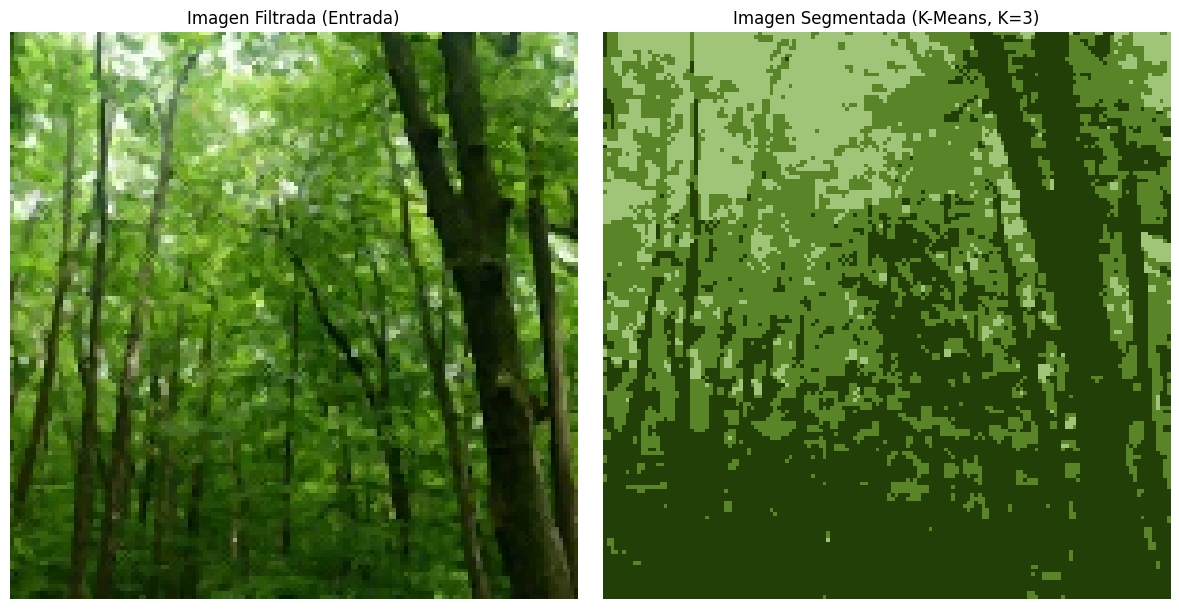

Colores representativos de cada segmento (en formato RGB de 0 a 1):
Segmento 1: [0.35 0.52 0.16]
Segmento 2: [0.13 0.25 0.03]
Segmento 3: [0.63 0.77 0.47]


In [75]:
# 1. Preparar los datos
# K-Means en OpenCV no recibe una matriz 3D (alto, ancho, canales). 
# Necesita una lista plana de píxeles, es decir, una matriz 2D de (numero_de_pixeles, 3)
datos_pixeles = imagen_filtrada.reshape((-1, 3))

# OpenCV exige estrictamente que los datos sean de tipo float32 para K-Means
datos_pixeles = np.float32(datos_pixeles)

# 2. Definir los parámetros de K-Means
# K es el número de segmentos (clases) en los que dividiremos la imagen. 
# Para paisajes, entre 3 y 5 suele dar excelentes resultados visuales.
K = 3 

# Criterio de parada: El algoritmo se detendrá cuando alcance 100 iteraciones 
# o cuando los centros de los grupos se muevan menos de 0.2 (epsilon)
criterio = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# 3. Aplicar el algoritmo
# Devuelve: el error (compactness), las etiquetas (a qué grupo pertenece cada píxel) 
# y los centros (el color RGB representativo de cada grupo)
_, etiquetas, centros = cv2.kmeans(datos_pixeles, K, None, criterio, 10, cv2.KMEANS_RANDOM_CENTERS)

# 4. Reconstruir la imagen segmentada
# Asignamos a cada píxel el color de su centro correspondiente
centros = np.float32(centros) # Aseguramos que los centros sean float
imagen_segmentada = centros[etiquetas.flatten()]

# Devolvemos la lista plana a su forma original de imagen 3D (alto, ancho, canales)
imagen_segmentada = imagen_segmentada.reshape(imagen_filtrada.shape)

# 5. Visualización
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(imagen_filtrada)
ax[0].set_title("Imagen Filtrada (Entrada)")
ax[0].axis('off')

ax[1].imshow(imagen_segmentada)
ax[1].set_title(f"Imagen Segmentada (K-Means, K={K})")
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Imprimimos los colores dominantes encontrados
print("Colores representativos de cada segmento (en formato RGB de 0 a 1):")
for i, color in enumerate(centros):
    print(f"Segmento {i+1}: {np.round(color, 2)}")

### **Deteccion de bordes**

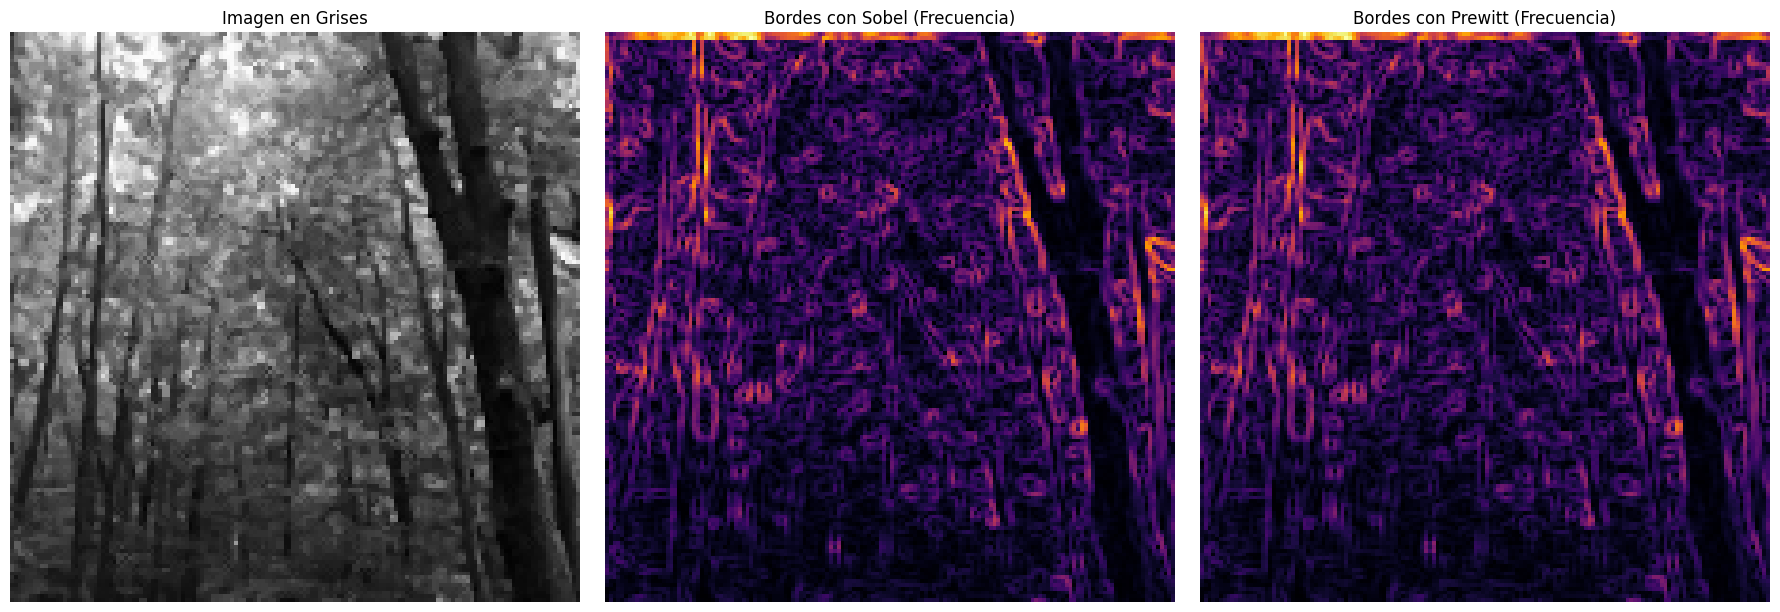

In [76]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift

# 1. Preparación: Convertir a escala de grises para detectar bordes
# (Usamos la imagen filtrada con mediana del paso anterior)
img_gris = cv2.cvtColor((imagen_filtrada * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
filas, columnas = img_gris.shape

# 2. Definir los Kernels en el espacio
# Sobel (Eje X y Eje Y)
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

# Prewitt (Eje X y Eje Y)
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

def filtrar_en_frecuencia(imagen, kernel):
    # a. Transformada de la imagen al dominio de la frecuencia
    f_img = fft2(imagen)
    
    # b. Padding del kernel para que tenga el mismo tamaño que la imagen
    # y convertir el kernel al dominio de la frecuencia
    f_kernel = fft2(kernel, s=imagen.shape)
    
    # c. Multiplicación en frecuencia (equivale a convolución en espacio)
    producto = f_img * f_kernel
    
    # d. Transformada inversa para volver al espacio
    resultado = np.real(ifft2(producto))
    return resultado

# 3. Aplicar filtrado
# Para Sobel
gx_sobel = filtrar_en_frecuencia(img_gris, sobel_x)
gy_sobel = filtrar_en_frecuencia(img_gris, sobel_y)
sobel_total = np.sqrt(gx_sobel**2 + gy_sobel**2)

# Para Prewitt
gx_prewitt = filtrar_en_frecuencia(img_gris, prewitt_x)
gy_prewitt = filtrar_en_frecuencia(img_gris, prewitt_y)
prewitt_total = np.sqrt(gx_prewitt**2 + gy_prewitt**2)

# 4. Visualización
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_gris, cmap='gray')
ax[0].set_title("Imagen en Grises")
ax[0].axis('off')

ax[1].imshow(sobel_total, cmap='inferno')
ax[1].set_title("Bordes con Sobel (Frecuencia)")
ax[1].axis('off')

ax[2].imshow(prewitt_total, cmap='inferno')
ax[2].set_title("Bordes con Prewitt (Frecuencia)")
ax[2].axis('off')

plt.tight_layout()
plt.show()

### **Histogramas**

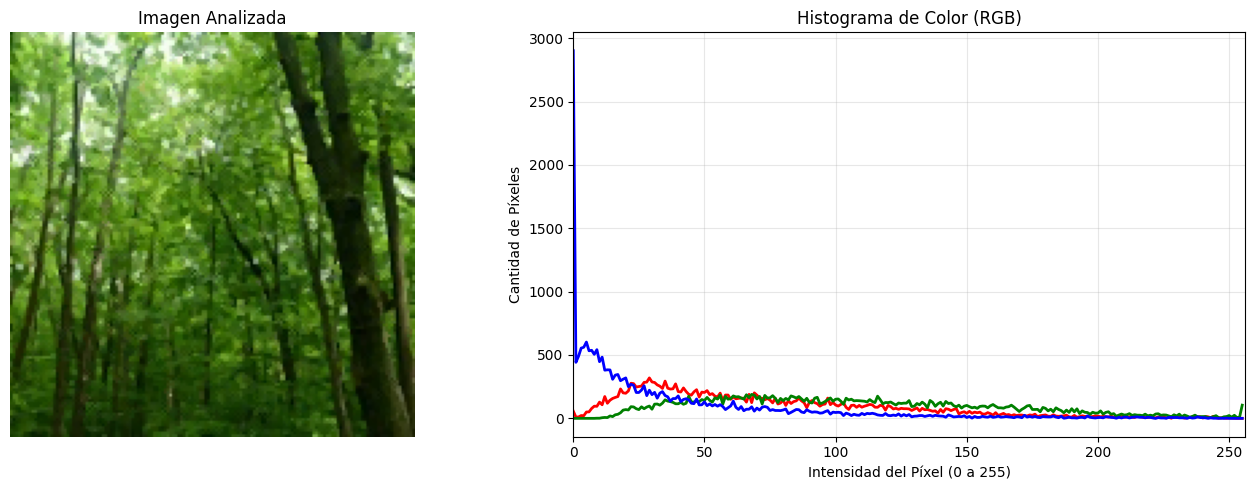

El histograma ha resumido la imagen en un vector numérico de 768 características.


In [77]:
# 1. Preparación de la imagen

img_para_hist = (imagen_filtrada * 255).astype(np.uint8)

# 2. Configuración del gráfico
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Mostramos la imagen de referencia
ax[0].imshow(img_para_hist)
ax[0].set_title("Imagen Analizada")
ax[0].axis('off')

# 3. Cálculo y ploteo de los histogramas
colores = ('red', 'green', 'blue')
ax[1].set_title("Histograma de Color (RGB)")
ax[1].set_xlabel("Intensidad del Píxel (0 a 255)")
ax[1].set_ylabel("Cantidad de Píxeles")
ax[1].set_xlim([0, 256])

# Iteramos sobre los canales: 0=Rojo, 1=Verde, 2=Azul
for i, color in enumerate(colores):
    # cv2.calcHist(imagenes, canales, mascara, tamaño_histograma, rangos)
    histograma = cv2.calcHist([img_para_hist], [i], None, [256], [0, 256])
    
    # Graficamos la línea del color correspondiente
    ax[1].plot(histograma, color=color, linewidth=2)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Extra: Cómo se vería esto como característica para tu modelo de ML
vector_caracteristicas = np.concatenate([
    cv2.calcHist([img_para_hist], [0], None, [256], [0, 256]),
    cv2.calcHist([img_para_hist], [1], None, [256], [0, 256]),
    cv2.calcHist([img_para_hist], [2], None, [256], [0, 256])
]).flatten()

print(f"El histograma ha resumido la imagen en un vector numérico de {len(vector_caracteristicas)} características.")

### **Ecualizacion**

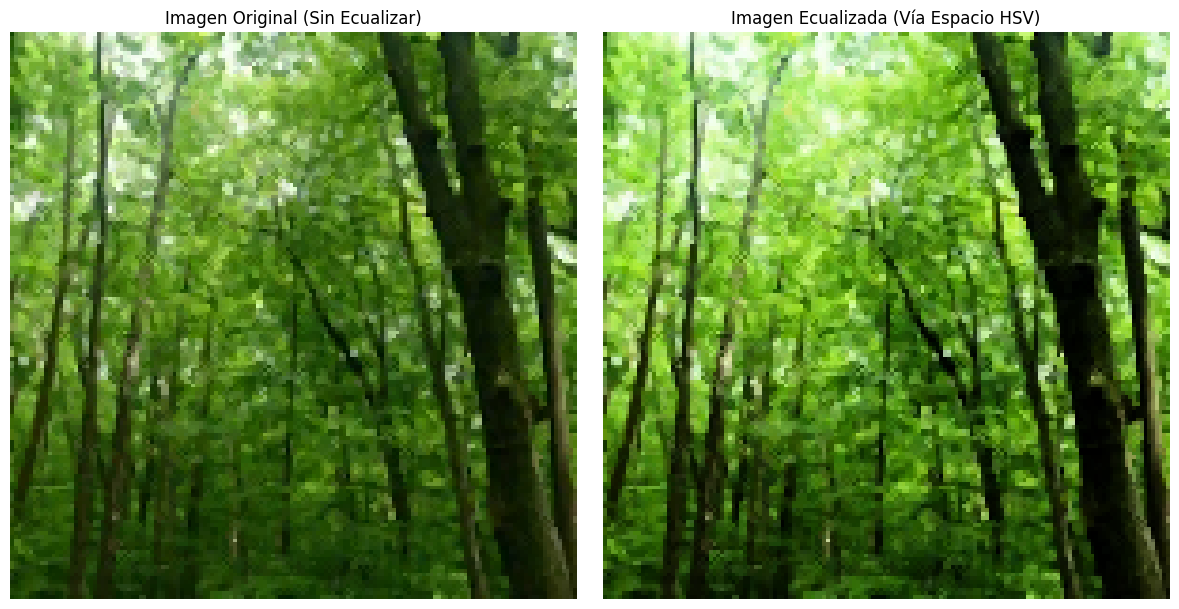

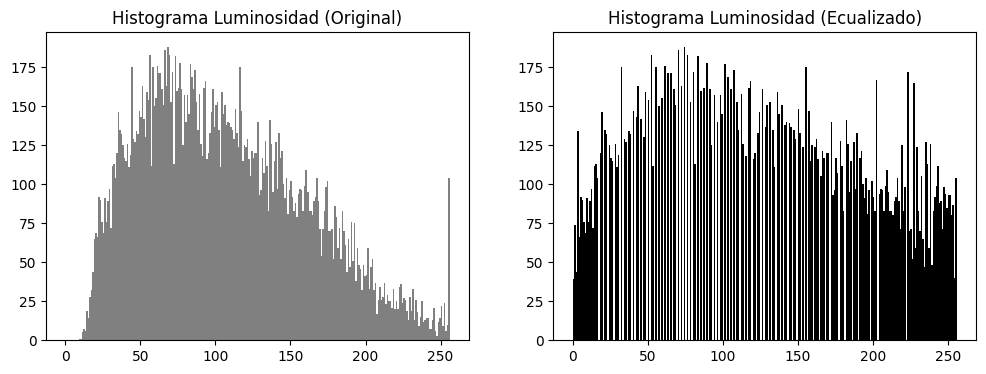

In [78]:
# 1. Convertir la imagen de RGB a HSV
img_hsv = cv2.cvtColor(img_para_hist, cv2.COLOR_RGB2HSV)

# 2. Separar los tres canales (H, S, V)
h, s, v = cv2.split(img_hsv)

# 3. Aplicar la ecualización del histograma SOLAMENTE al canal V (Luminosidad)
v_ecualizado = cv2.equalizeHist(v)

# 4. Volver a unir los canales con el V ya mejorado
img_hsv_ecualizada = cv2.merge((h, s, v_ecualizado))

# 5. Convertir la imagen de vuelta al espacio RGB para poder visualizarla
img_ecualizada_rgb = cv2.cvtColor(img_hsv_ecualizada, cv2.COLOR_HSV2RGB)

# 6. Visualización comparativa
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_para_hist)
ax[0].set_title("Imagen Original (Sin Ecualizar)")
ax[0].axis('off')

ax[1].imshow(img_ecualizada_rgb)
ax[1].set_title("Imagen Ecualizada (Vía Espacio HSV)")
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Para ver qué pasó matemáticamente, calculemos el histograma del canal V original vs ecualizado
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
ax2[0].hist(v.flatten(), bins=256, range=[0,256], color='gray')
ax2[0].set_title("Histograma Luminosidad (Original)")
ax2[1].hist(v_ecualizado.flatten(), bins=256, range=[0,256], color='black')
ax2[1].set_title("Histograma Luminosidad (Ecualizado)")
plt.show()

Has destruido la "firma lumínica" del bosque. El modelo original habría visto un histograma concentrado a la izquierda y habría aprendido que "oscuro = bosque". Ahora, el modelo verá un histograma que abarca todo el espectro (muy similar al que tendría un glaciar en un día soleado), lo que aumentará la probabilidad de que se confunda al clasificar.

### **Calculo de PSNR**

In [79]:
import math

def calcular_psnr(img_original, img_filtrada):
    # 1. Calcular el Error Cuadrático Medio (MSE)
    # Comparamos pixel a pixel la diferencia entre ambas imágenes
    mse = np.mean((img_original - img_filtrada) ** 2)
    
    # Si el error es 0, las imágenes son idénticas y el PSNR es infinito
    if mse == 0:
        return float('inf')
        
    # 2. Definir el valor máximo posible del píxel
    # Como nuestras imágenes están normalizadas entre 0.0 y 1.0, el máximo es 1.0.
    # Si estuvieran en escala 0-255, este valor sería 255.0
    max_pixel = 1.0
    
    # 3. Aplicar la fórmula logarítmica del PSNR
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    
    return psnr

# Ejecutamos la función con nuestras matrices
# (Recuerda que imagen_normalizada es la original sin ruido, 
# e imagen_filtrada es la que recuperamos con el filtro de mediana)
valor_psnr = calcular_psnr(imagen_normalizada, imagen_filtrada)

print("--- Evaluación del Filtrado ---")
print(f"Valor PSNR obtenido: {valor_psnr:.2f} dB")

# Interpretación rápida para tu documento:
if valor_psnr >= 30:
    print("Interpretación: Excelente recuperación. El filtro eliminó el ruido preservando la calidad.")
elif 20 <= valor_psnr < 30:
    print("Interpretación: Recuperación aceptable. Hay una pérdida notable de calidad o el filtro difuminó mucho la imagen.")
else:
    print("Interpretación: Mala recuperación. La imagen filtrada es muy diferente a la original.")

--- Evaluación del Filtrado ---
Valor PSNR obtenido: 21.84 dB
Interpretación: Recuperación aceptable. Hay una pérdida notable de calidad o el filtro difuminó mucho la imagen.
